In [1]:
# Working on locating EDMR features 
# from simulated spectra

In [2]:
import sys
from pathlib import Path
project_root = Path().resolve().parent.parent.parent
sys.path.insert(0, str(project_root))

import time
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.signal import find_peaks
from functools import cached_property
from sweeping.main.parse_cdf import RenderNetCDF 

plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

In [3]:
# Getting raw data 

cdf_filename = "sweep.nc" 
render = RenderNetCDF(cdf_filename) 

# extracting example EDMR spectra 
# with specific parameter values 
slice = render.slice(
    parameter_values={
        "nu": 1.98e8, 
        "omega1": 2.0e5
    }
)

B  = slice.B   # Field Strength [G] 
dI = slice.dI  # Lock-in Derivative 
I  = slice.I   # Integrated Current [nA] 

# extending to full resonance-to-resonance specrtra 
B_neg  = -B[1:][::-1]             
dI_neg = -dI[1:][::-1]
I_neg  = I[1:][::-1]

B  = np.concatenate([B_neg, B]) 
dI = np.concatenate([dI_neg, dI])
I  = np.concatenate([I_neg, I])

In [4]:
class FindFeatures: 
    def __init__(
        self, 
        B:  np.ndarray, 
        dI: np.ndarray, 
        I:  np.ndarray, 
    ): 
        self.B  = B   # Field Strength 
        self.dI = dI  # Lock-in Derivative Current 
        self.I  = I   # Integrated Current 

    @cached_property
    def find_peaks(self): 
        maxima_idxs, _ = find_peaks(self.dI) 
        minima_idxs, _ = find_peaks(-self.dI)
        return maxima_idxs, minima_idxs 

    @cached_property
    def zero_crossings(self): 
        start = time.time() 
        maxima_idxs, minima_idxs = self.find_peaks
        end   = time.time() 

        print(f"Time Taken: {end - start}s")

        # rough midpoints of lock-in current
        # gives the maxima of integrated current 
        return (maxima_idxs + minima_idxs) // 2 

    @property 
    def maxima_idxs(self): 
        return self.zero_crossings

    @property 
    def maxima_B(self): 
        return self.B[self.maxima_idxs] 

    @property 
    def maxima_dI(self): 
        return self.dI[self.maxima_idxs]

    @property 
    def maxima_I(self): 
        return self.I[self.maxima_idxs] 

In [5]:
findfeatures = FindFeatures(
    B=B, 
    dI=dI, 
    I=I, 
)

maxima_B  = findfeatures.maxima_B  # B values of features 
maxima_I  = findfeatures.maxima_I  # I values of features 
maxima_dI = findfeatures.maxima_dI # dI values of features 

Time Taken: 0.00020194053649902344s


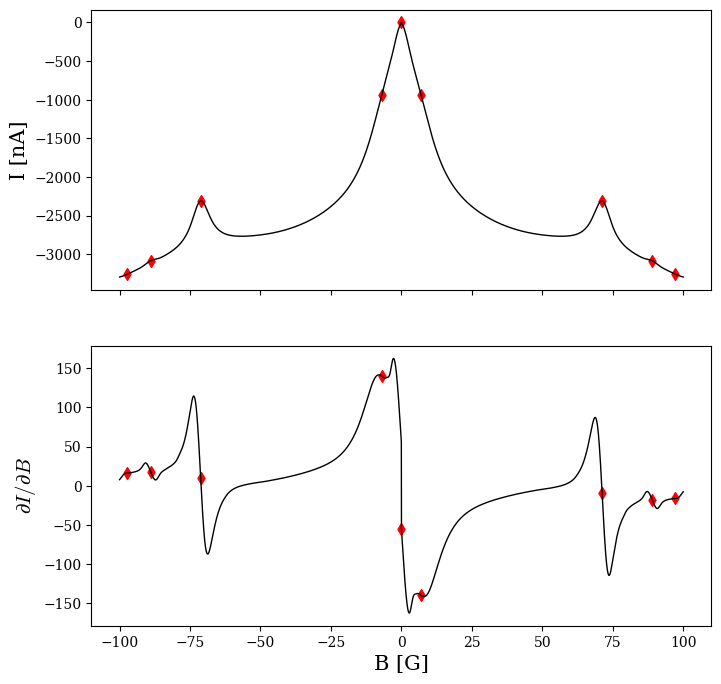

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax[0].plot(B, I, c='k', linewidth=1, linestyle='-')
ax[0].scatter(maxima_B, maxima_I, c='r', marker='d')

ax[1].plot(B, dI, c='k', linewidth=1, linestyle='-') 
ax[1].scatter(maxima_B, maxima_dI, c='r', marker='d')

ax[1].set_xlabel("B [G]", fontsize=15) 
ax[0].set_ylabel("I [nA]", fontsize=15) 
ax[1].set_ylabel(r"$\partial I / \partial B$", fontsize=15)

plt.show()